<a href="https://colab.research.google.com/github/khiba-k/Python_ML_Linear_Regression/blob/main/recovery_score_vs_dosage_polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [45]:
# Load Data into dataframe
data = {
    'dosage_mg': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150],
    'recovery_score': [32, 58, 75, 88, 96, 99, 97, 91, 80, 68, 54, 41, 30, 22, 15]
}
df = pd.DataFrame(data)

In [46]:
# Split Data into feature(s) and results
features = df.iloc[:, :-1].values
results = df.iloc[:, -1].values

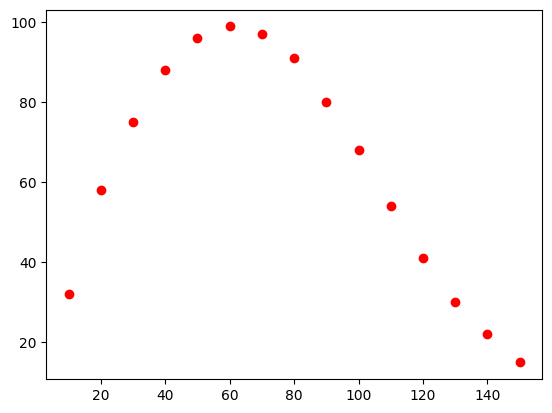

In [47]:
# Visualize the data to get best suited model
plt.scatter(features, results, color="red")
plt.show()

In [48]:
# Split the data into training and testing
training_features, test_features, training_results, test_results = train_test_split(features, results, test_size=0.33, random_state=42)

In [49]:
# Insert the additional polynomial features
poly_reg = PolynomialFeatures(degree=2)
poly_training_features = poly_reg.fit_transform(training_features)
poly_test_features = poly_reg.fit_transform(test_features)

In [50]:
# Train Model & Predict the results
linear_reg = LinearRegression()
linear_reg.fit(poly_training_features, training_results)
predicted_test_results = linear_reg.predict(poly_test_features)
predicted_training_results = linear_reg.predict(poly_training_features)

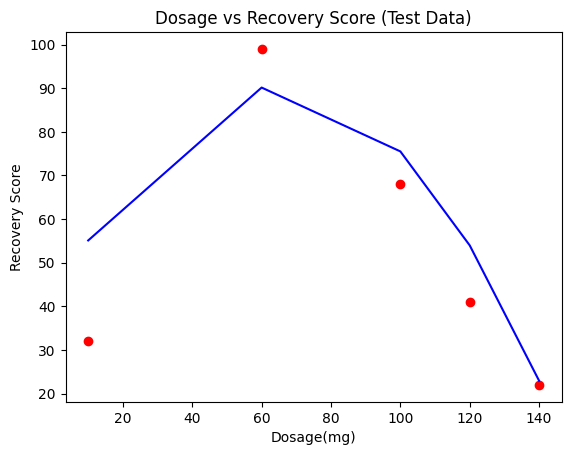

In [51]:
# Visualize the Testing Predictions vs Actual testing results
plt.scatter(test_features, test_results, color='red')
sorted_idx = test_features.flatten().argsort()
sorted_test_features = test_features[sorted_idx]
sorted_test_predictions = predicted_test_results[sorted_idx]
plt.plot(sorted_test_features, sorted_test_predictions, color='blue')
plt.title("Dosage vs Recovery Score (Test Data)")
plt.xlabel("Dosage(mg)")
plt.ylabel("Recovery Score")
plt.show()

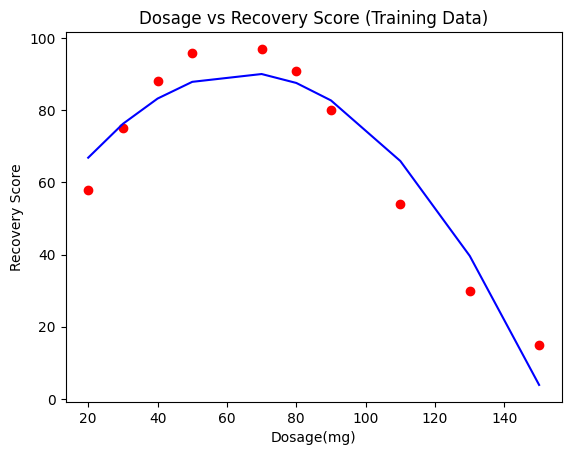

In [59]:
# Visualize the Testing Predictions vs Actual testing results
plt.scatter(training_features, training_results, color='red')
sorted_idx = training_features.flatten().argsort()
sorted_train_features = training_features[sorted_idx]
sorted_train_predictions = predicted_training_results[sorted_idx]
plt.plot(sorted_train_features, sorted_train_predictions, color='blue')
plt.title("Dosage vs Recovery Score (Training Data)")
plt.xlabel("Dosage(mg)")
plt.ylabel("Recovery Score")
plt.show()

In [69]:
# Print Actual Test Results vs Predicted Test Results
actual_vs_predicted_results = np.concatenate(([test_results], [predicted_test_results]), axis=0)
np.set_printoptions(precision=2)
print(np.concatenate((test_results.reshape(len(test_results), 1), predicted_test_results.reshape(len(predicted_test_results), 1)), axis=1))

[[68.   75.51]
 [41.   53.97]
 [32.   55.11]
 [22.   22.95]
 [99.   90.15]]
